In [4]:
!pip install -q e2cnn torch torchvision scikit-learn seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.3/225.3 kB 9.2 MB/s eta 0:00:00


In [5]:
from google.colab import drive
drive.mount('/content/drive')

import os, zipfile

# ---- Path to your Drive folder ----
DRIVE_PATH = '/content/drive/MyDrive/galaxy_zoo/galaxy-zoo-the-galaxy-'
# Adjust if folder name is slightly different — check with:
# !ls "/content/drive/MyDrive/galaxy_zoo/"

DATA_DIR   = '/content/galaxy_data'
IMAGES_DIR = os.path.join(DATA_DIR, 'images_training_rev1')
LABELS_CSV = os.path.join(DATA_DIR, 'training_solutions_rev1.csv')

os.makedirs(DATA_DIR, exist_ok=True)

# ---- Unzip only if not already done ----
def unzip_if_needed(zip_src, dest_dir, check_file):
    if not os.path.exists(check_file):
        print(f"Unzipping {os.path.basename(zip_src)} ...")
        with zipfile.ZipFile(zip_src, 'r') as z:
            z.extractall(dest_dir)
        print("  Done.")
    else:
        print(f"  Already unzipped: {os.path.basename(zip_src)}")

# Find the actual folder path (handles partial name)
import glob
matches = glob.glob('/content/drive/MyDrive/galaxy_zoo/galaxy-zoo*')
if matches:
    DRIVE_FOLDER = matches[0]
    print(f"Found Drive folder: {DRIVE_FOLDER}")
else:
    DRIVE_FOLDER = '/content/drive/MyDrive/galaxy_zoo'
    print("Folder not auto-found — using default path. Edit DRIVE_FOLDER manually if needed.")

unzip_if_needed(
    os.path.join(DRIVE_FOLDER, 'training_solutions_rev1.zip'),
    DATA_DIR,
    LABELS_CSV
)
unzip_if_needed(
    os.path.join(DRIVE_FOLDER, 'images_training_rev1.zip'),
    DATA_DIR,
    IMAGES_DIR
)

print(f"\nImages dir exists : {os.path.exists(IMAGES_DIR)}")
print(f"Labels CSV exists : {os.path.exists(LABELS_CSV)}")
print(f"Sample images     : {len(os.listdir(IMAGES_DIR)):,}")

Mounted at /content/drive
Found Drive folder: /content/drive/MyDrive/galaxy_zoo/galaxy-zoo-the-galaxy-challenge (Unzipped Files)
Unzipping training_solutions_rev1.zip ...
  Done.
Unzipping images_training_rev1.zip ...
  Done.

Images dir exists : True
Labels CSV exists : True
Sample images     : 61,578


Now we will be importing all of the neccessory Dependencies & Global Config.

In [6]:
import torch, os, time, copy, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
from PIL import Image
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, auc,
                             precision_score, recall_score, f1_score)
from sklearn.preprocessing import label_binarize
import e2cnn.gspaces as gspaces
import e2cnn.nn as enn

warnings.filterwarnings('ignore')

DEVICE      = 'cuda' if torch.cuda.is_available() else 'cpu'
BATCH_SIZE  = 64
EPOCHS      = 15
LR          = 1e-3
NUM_CLASSES = 4
IMG_SIZE    = 64
SEED        = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

CLASS_NAMES = ['Elliptical', 'Merger', 'Spiral_Active', 'Spiral_Mature']
print(f"Device  : {DEVICE}")
print(f"ImgSize : {IMG_SIZE}x{IMG_SIZE} | Batch: {BATCH_SIZE} | Epochs: {EPOCHS}")

Device  : cuda
ImgSize : 64x64 | Batch: 64 | Epochs: 15


In [7]:
# ================================================================
# STEP 1: DATASET COLLECTION
# ================================================================
df = pd.read_csv(LABELS_CSV)
print(f"Labels CSV shape : {df.shape}")
print(f"Columns          : {list(df.columns[:8])} ...")
print(df.head(3))

# ---- Map vote fractions → 4 evolutionary stage classes ----
# Class1.1 = smooth (Elliptical)
# Class6.2 = merger/disturbed
# Class10.1 = tight spiral arms (Spiral Active)
# else = Spiral Mature

def assign_label(row):
    smooth  = row.get('Class1.1', 0)
    merger  = row.get('Class6.2', 0)
    tight   = row.get('Class10.1', 0)
    if   smooth > 0.70: return 0  # Elliptical
    elif merger > 0.30: return 1  # Merger
    elif tight  > 0.40: return 2  # Spiral Active
    else:               return 3  # Spiral Mature

df['label'] = df.apply(assign_label, axis=1)
df['image_path'] = df['GalaxyID'].apply(
    lambda gid: os.path.join(IMAGES_DIR, f'{int(gid)}.jpg')
)

# Keep only rows where image file actually exists
df = df[df['image_path'].apply(os.path.exists)].reset_index(drop=True)

print(f"\nTotal valid samples : {len(df):,}")
print("\nClass distribution:")
for i, name in enumerate(CLASS_NAMES):
    n = (df['label'] == i).sum()
    print(f"  {i} - {name:>15} : {n:,}  ({n/len(df)*100:.1f}%)")

Labels CSV shape : (61578, 38)
Columns          : ['GalaxyID', 'Class1.1', 'Class1.2', 'Class1.3', 'Class2.1', 'Class2.2', 'Class3.1', 'Class3.2'] ...
   GalaxyID  Class1.1  Class1.2  Class1.3  Class2.1  Class2.2  Class3.1  \
0    100008  0.383147  0.616853  0.000000  0.000000  0.616853  0.038452   
1    100023  0.327001  0.663777  0.009222  0.031178  0.632599  0.467370   
2    100053  0.765717  0.177352  0.056931  0.000000  0.177352  0.000000   

   Class3.2  Class4.1  Class4.2  ...  Class9.3  Class10.1  Class10.2  \
0  0.578401  0.418398  0.198455  ...  0.000000   0.279952   0.138445   
1  0.165229  0.591328  0.041271  ...  0.018764   0.000000   0.131378   
2  0.177352  0.000000  0.177352  ...  0.000000   0.000000   0.000000   

   Class10.3  Class11.1  Class11.2  Class11.3  Class11.4  Class11.5  Class11.6  
0    0.00000        0.0   0.092886        0.0        0.0        0.0   0.325512  
1    0.45995        0.0   0.591328        0.0        0.0        0.0   0.000000  
2    0.00000    

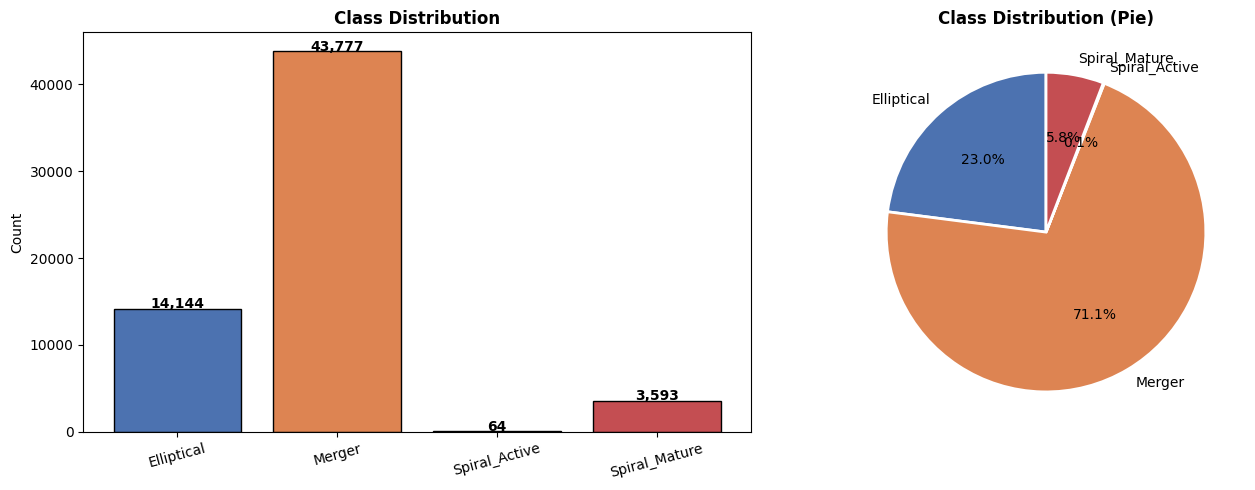

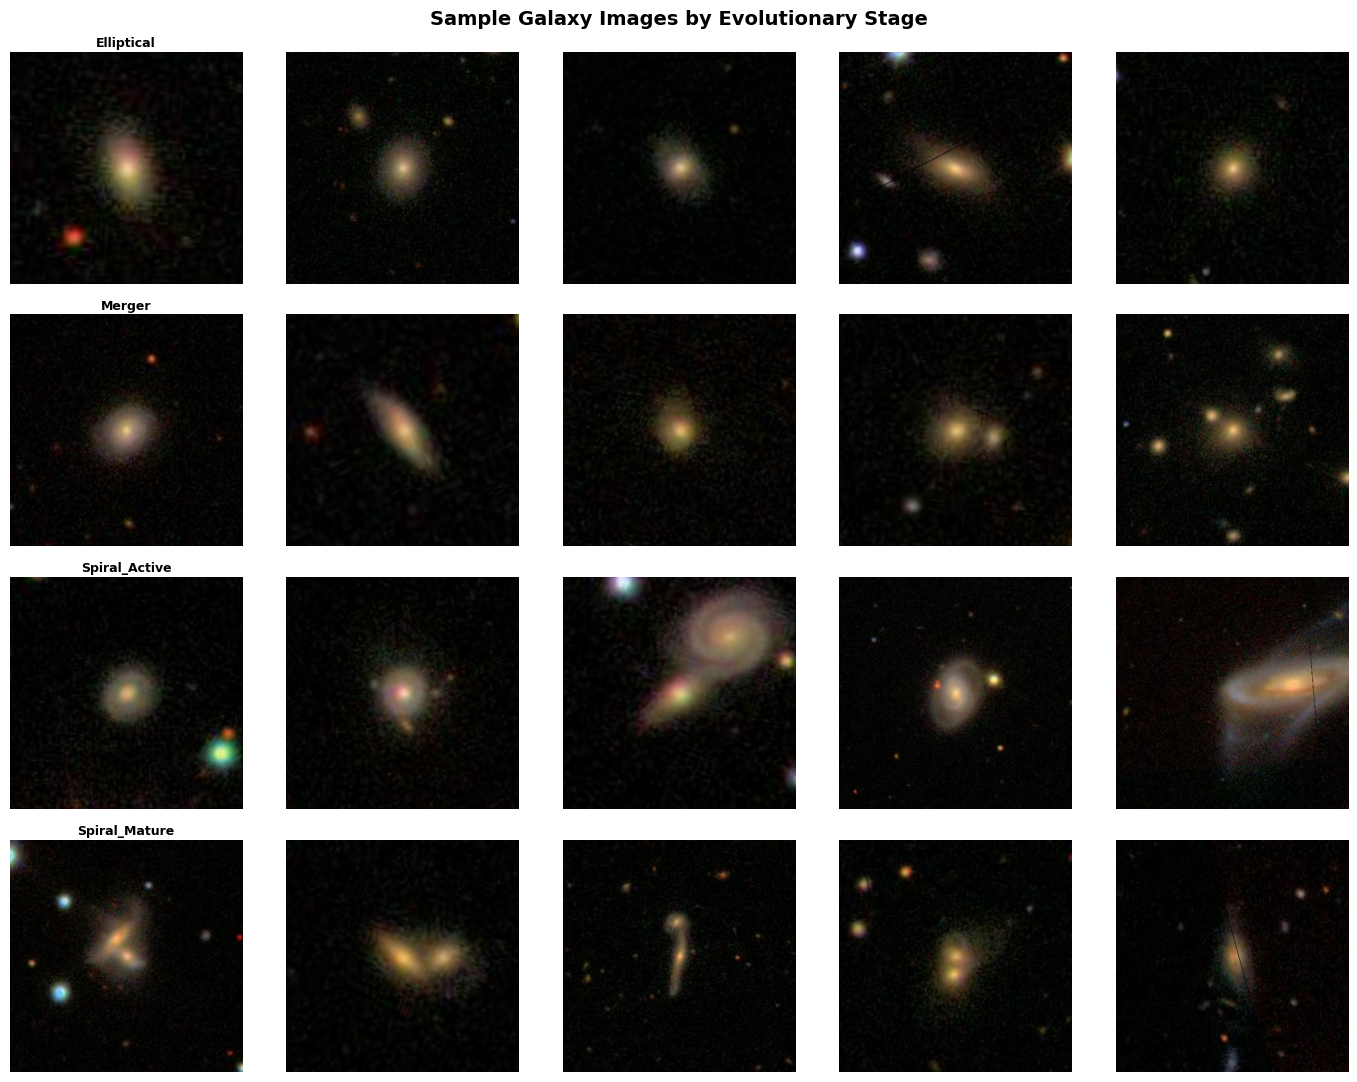

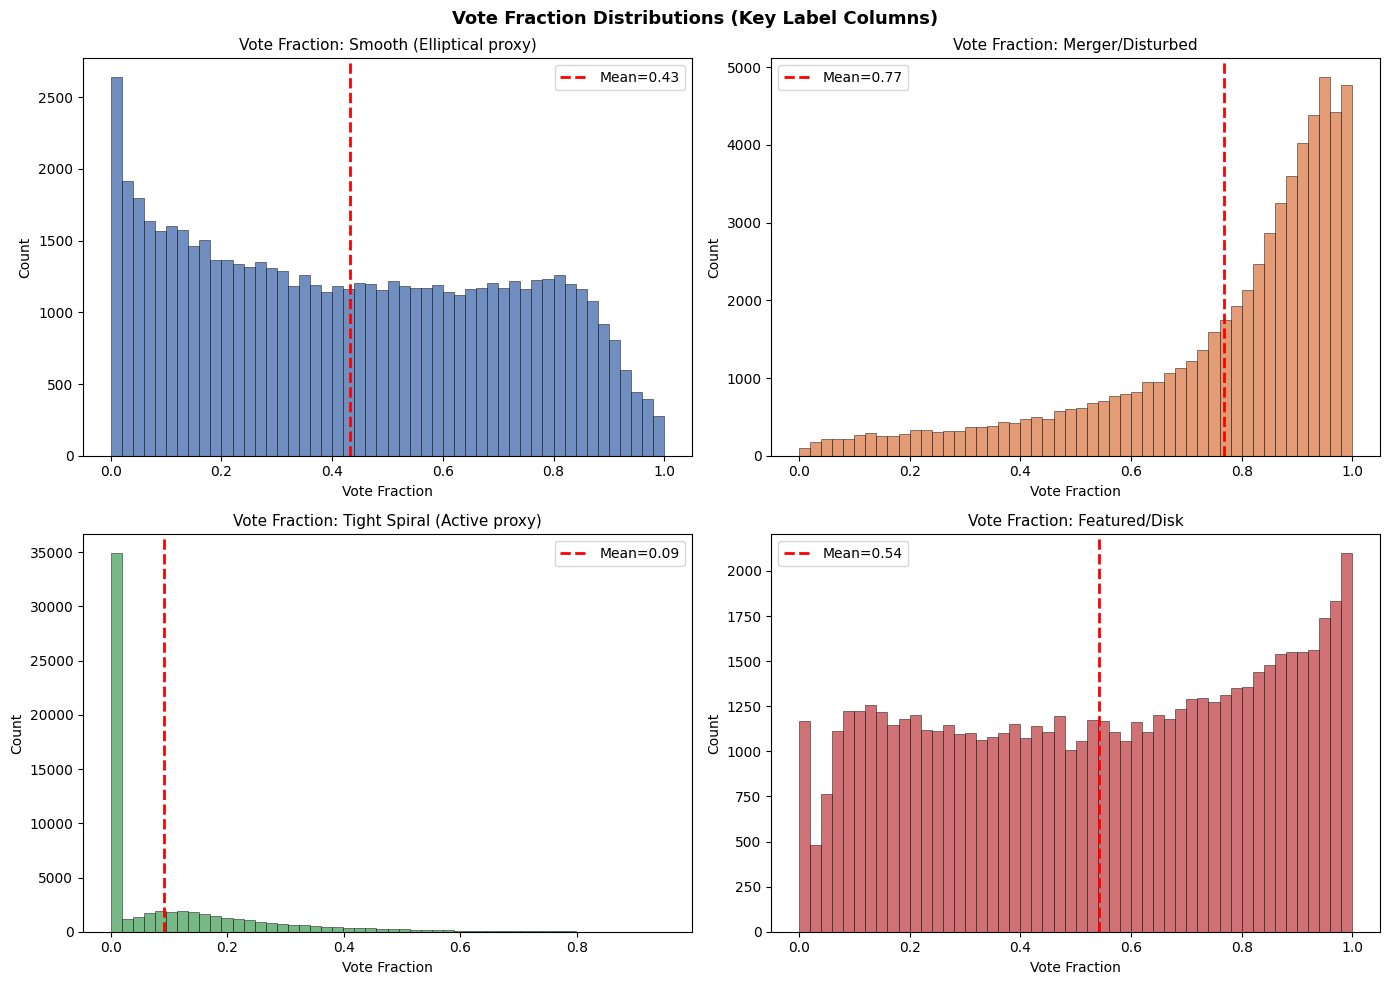

[EDA] Sampling 200 images for brightness analysis...


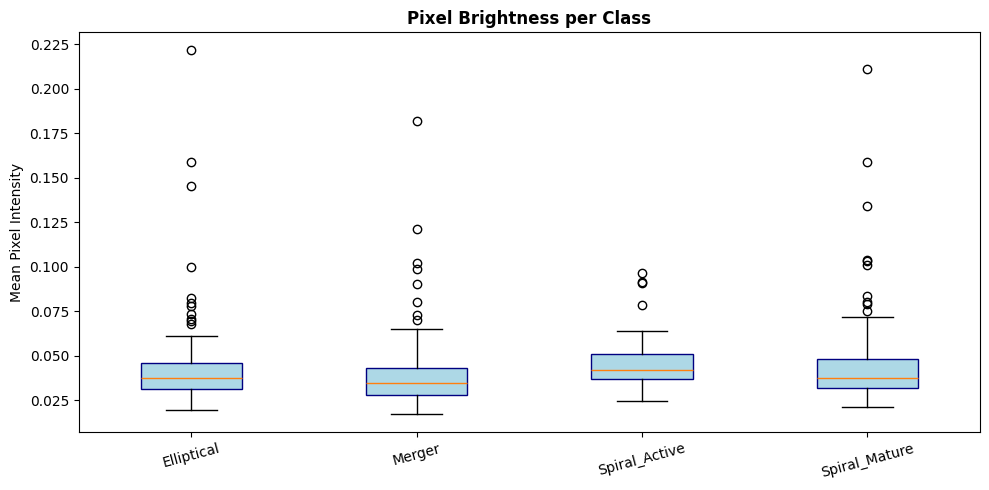


✅ EDA complete


In [8]:
# STEP 2: EXPLORATORY DATA ANALYSIS

counts = [( df['label'] == i).sum() for i in range(NUM_CLASSES)]

# ---- 1. Class Distribution ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bars = axes[0].bar(CLASS_NAMES, counts,
                   color=['#4C72B0','#DD8452','#55A868','#C44E52'], edgecolor='black')
for bar, v in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
                 f'{v:,}', ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Class Distribution', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count'); axes[0].tick_params(axis='x', rotation=15)

axes[1].pie(counts, labels=CLASS_NAMES, autopct='%1.1f%%',
            colors=['#4C72B0','#DD8452','#55A868','#C44E52'],
            startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Class Distribution (Pie)', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.savefig('eda_class_distribution.png', dpi=150); plt.show()

# ---- 2. Sample Images per Class ----
fig, axes = plt.subplots(4, 5, figsize=(14, 11))
fig.suptitle('Sample Galaxy Images by Evolutionary Stage', fontsize=14, fontweight='bold')

for row, cls in enumerate(range(NUM_CLASSES)):
    cls_df = df[df['label'] == cls].head(5)
    for col, (_, sample) in enumerate(cls_df.iterrows()):
        ax = axes[row][col]
        img = Image.open(sample['image_path']).convert('RGB')
        ax.imshow(img); ax.axis('off')
        if col == 0:
            ax.set_title(CLASS_NAMES[cls], fontsize=9, fontweight='bold', pad=4)
plt.tight_layout(); plt.savefig('eda_sample_images.png', dpi=150); plt.show()

# ---- 3. Vote Fraction Distributions ----
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
vote_cols = ['Class1.1', 'Class6.2', 'Class10.1', 'Class1.2']
vote_titles = ['Smooth (Elliptical proxy)', 'Merger/Disturbed', 'Tight Spiral (Active proxy)', 'Featured/Disk']
colors = ['#4C72B0','#DD8452','#55A868','#C44E52']

for ax, col, title, color in zip(axes.flat, vote_cols, vote_titles, colors):
    ax.hist(df[col], bins=50, color=color, alpha=0.8, edgecolor='black', linewidth=0.4)
    ax.axvline(df[col].mean(), color='red', linestyle='--', lw=2, label=f'Mean={df[col].mean():.2f}')
    ax.set_title(f'Vote Fraction: {title}', fontsize=11)
    ax.set_xlabel('Vote Fraction'); ax.set_ylabel('Count'); ax.legend()
plt.suptitle('Vote Fraction Distributions (Key Label Columns)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('eda_vote_fractions.png', dpi=150); plt.show()

# ---- 4. Pixel Brightness by Class ----
print("[EDA] Sampling 200 images for brightness analysis...")
brightness = {c: [] for c in range(NUM_CLASSES)}
for cls in range(NUM_CLASSES):
    for path in df[df['label']==cls]['image_path'].head(200):
        img_arr = np.array(Image.open(path).convert('RGB').resize((64,64))) / 255.0
        brightness[cls].append(img_arr.mean())

fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot([brightness[c] for c in range(NUM_CLASSES)],
           labels=CLASS_NAMES, patch_artist=True,
           boxprops=dict(facecolor='lightblue', color='navy'))
ax.set_title('Pixel Brightness per Class', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Pixel Intensity'); ax.tick_params(axis='x', rotation=15)
plt.tight_layout(); plt.savefig('eda_brightness.png', dpi=150); plt.show()

print("\n✅ EDA complete")

[Cleaning] Scanning for corrupted images (sample of 1000)...
  Checked    : 1,000
  Corrupted  : 0
  Clean rows : 61,578

[Preprocessing] Computing channel mean/std from 500 random samples...
  MEAN : [0.0464, 0.0404, 0.03]
  STD  : [0.0809, 0.0675, 0.0577]


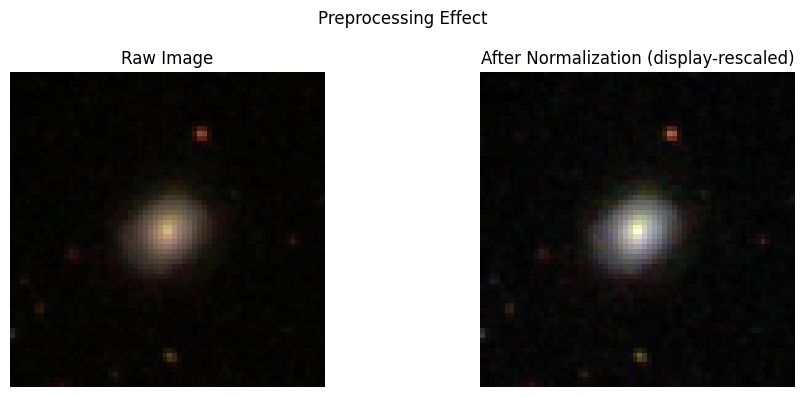


✅ Cleaning & Preprocessing done


In [9]:
# STEP 3: DATA CLEANING & PREPROCESSING

# ---- 1. Check for corrupted images ----
print("[Cleaning] Scanning for corrupted images (sample of 1000)...")
bad = []
for i, row in df.head(1000).iterrows():
    try:
        img = Image.open(row['image_path']).convert('RGB')
        arr = np.array(img)
        if arr.sum() == 0: bad.append(i)
    except:
        bad.append(i)

print(f"  Checked    : 1,000")
print(f"  Corrupted  : {len(bad)}")
df_clean = df.drop(index=bad).reset_index(drop=True)
print(f"  Clean rows : {len(df_clean):,}")

# ---- 2. Compute dataset normalization stats ----
print("\n[Preprocessing] Computing channel mean/std from 500 random samples...")
sample_df = df_clean.sample(500, random_state=SEED)
means, stds = [], []
basic_t = transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.ToTensor()])
for path in sample_df['image_path']:
    t = basic_t(Image.open(path).convert('RGB'))
    means.append(t.mean(dim=[1,2]).numpy())
    stds.append(t.std(dim=[1,2]).numpy())

DATA_MEAN = np.array(means).mean(axis=0).tolist()
DATA_STD  = [max(s, 0.01) for s in np.array(stds).mean(axis=0).tolist()]
print(f"  MEAN : {[round(m,4) for m in DATA_MEAN]}")
print(f"  STD  : {[round(s,4) for s in DATA_STD]}")

# ---- 3. Visualize effect of normalization ----
sample_img_path = df_clean['image_path'].iloc[0]
raw_img  = basic_t(Image.open(sample_img_path).convert('RGB'))
norm_img = transforms.Normalize(DATA_MEAN, DATA_STD)(raw_img)
disp_img = (norm_img - norm_img.min()) / (norm_img.max() - norm_img.min())

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(raw_img.permute(1,2,0).numpy()); axes[0].set_title('Raw Image'); axes[0].axis('off')
axes[1].imshow(disp_img.permute(1,2,0).numpy()); axes[1].set_title('After Normalization (display-rescaled)'); axes[1].axis('off')
plt.suptitle('Preprocessing Effect', fontsize=12); plt.tight_layout()
plt.savefig('preprocessing_comparison.png', dpi=150); plt.show()

print("\n✅ Cleaning & Preprocessing done")

In [10]:
# ================================================================
# STEP 4: FEATURE ENGINEERING & SELECTION
# ================================================================

# ---- Final transforms per model ----
train_transform_cnn = transforms.Compose([
    transforms.Resize((IMG_SIZE + 8, IMG_SIZE + 8)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(degrees=180),    # CNN needs this
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(DATA_MEAN, DATA_STD)
])

train_transform_gcnn = transforms.Compose([
    transforms.Resize((IMG_SIZE + 8, IMG_SIZE + 8)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),                     # No rotation — p4m handles it
    transforms.Normalize(DATA_MEAN, DATA_STD)
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(DATA_MEAN, DATA_STD)
])

print("Transform pipelines:")
print("  CNN  train : Resize→Crop→HFlip→Rotate(180°)→Jitter→Normalize")
print("  GCNN train : Resize→Crop→Jitter→Normalize  (NO rotation needed)")
print("  Val/Test   : Resize→Normalize only")
print("\n✅ Feature Engineering done")

Transform pipelines:
  CNN  train : Resize→Crop→HFlip→Rotate(180°)→Jitter→Normalize
  GCNN train : Resize→Crop→Jitter→Normalize  (NO rotation needed)
  Val/Test   : Resize→Normalize only

✅ Feature Engineering done


In [11]:
# ================================================================
# STEP 5: TRAIN-TEST SPLIT
# ================================================================
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split

# ---- 70 / 15 / 15 stratified split ----
train_df, temp_df = train_test_split(
    df_clean, test_size=0.30, random_state=SEED, stratify=df_clean['label'])
val_df, test_df = train_test_split(
    temp_df,  test_size=0.50, random_state=SEED, stratify=temp_df['label'])

print(f"  Train : {len(train_df):,}")
print(f"  Val   : {len(val_df):,}")
print(f"  Test  : {len(test_df):,}")

# ---- Custom Dataset class ----
class GalaxyDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        img   = Image.open(row['image_path']).convert('RGB')
        label = int(row['label'])
        if self.transform:
            img = self.transform(img)
        return img, label

# ---- DataLoaders ----
train_ds_cnn  = GalaxyDataset(train_df, train_transform_cnn)
train_ds_gcnn = GalaxyDataset(train_df, train_transform_gcnn)
val_ds        = GalaxyDataset(val_df,   val_transform)
test_ds       = GalaxyDataset(test_df,  val_transform)

train_loader_cnn  = DataLoader(train_ds_cnn,  batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
train_loader_gcnn = DataLoader(train_ds_gcnn, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader        = DataLoader(val_ds,         batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader       = DataLoader(test_ds,        batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# ---- Quick batch test ----
imgs, labels = next(iter(train_loader_cnn))
print(f"\nBatch shape : {imgs.shape}  |  Labels: {labels[:8].tolist()}")
print("\n✅ Train-Test Split done")

  Train : 43,104
  Val   : 9,237
  Test  : 9,237

Batch shape : torch.Size([64, 3, 64, 64])  |  Labels: [1, 1, 0, 1, 0, 1, 0, 1]

✅ Train-Test Split done


In [12]:
import os

# ---- Patch 1: irreps_basis.py (tostring → tobytes) ----
path1 = '/usr/local/lib/python3.12/dist-packages/e2cnn/kernels/irreps_basis.py'

with open(path1, 'r') as f:
    code = f.read()

fixed = code.replace('.tostring()', '.tobytes()')

with open(path1, 'w') as f:
    f.write(fixed)

print(f"✅ Patched irreps_basis.py")

# ---- Patch 2: utils.py (np.array copy=False → np.asarray) ----
path2 = '/usr/local/lib/python3.12/dist-packages/e2cnn/kernels/utils.py'

with open(path2, 'r') as f:
    code = f.read()

fixed = code.replace('np.array(s, copy=False)',     'np.asarray(s)')\
            .replace('np.array(k, copy=False)',     'np.asarray(k)')\
            .replace('np.array(gamma, copy=False)', 'np.asarray(gamma)')

with open(path2, 'w') as f:
    f.write(fixed)

print(f"✅ Patched utils.py")

# ---- Verify patches ----
with open(path1, 'r') as f:
    c = f.read()
print(f"  tostring remaining in irreps_basis : {c.count('.tostring()')}")  # Should be 0

with open(path2, 'r') as f:
    c = f.read()
print(f"  copy=False remaining in utils      : {c.count('copy=False')}")   # Should be 0

print("\n✅ All patches done — now re-run Cell 9 directly")

✅ Patched irreps_basis.py
✅ Patched utils.py
  tostring remaining in irreps_basis : 0
  copy=False remaining in utils      : 0

✅ All patches done — now re-run Cell 9 directly


In [13]:
# ================================================================
# STEP 6: MODEL BUILDING
# Model 1: ResNet-18 (Standard CNN)
# Model 2: EfficientNet-B0 (Lightweight CNN with compound scaling)
# ================================================================

NUM_CLASSES = 4

# ---- Model 1: Standard ResNet-18 ----
def build_standard_cnn(num_classes=NUM_CLASSES):
    model = models.resnet18(weights=None)
    model.conv1   = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    model.fc = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(model.fc.in_features, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(0.2),
        nn.Linear(256, num_classes)
    )
    return model

# ---- Model 2: EfficientNet-B0 ----
def build_efficientnet(num_classes=NUM_CLASSES, dropout=0.4):
    model = models.efficientnet_b0(weights=None)
    # Replace classifier head
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(in_features, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(0.2),
        nn.Linear(256, num_classes)
    )
    return model

# ---- Sanity check ----
dummy = torch.zeros(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
_cnn  = build_standard_cnn().to(DEVICE)
_eff  = build_efficientnet().to(DEVICE)

cnn_params = sum(p.numel() for p in _cnn.parameters() if p.requires_grad)
eff_params = sum(p.numel() for p in _eff.parameters() if p.requires_grad)

print(f"  ResNet-18       output: {_cnn(dummy).shape}  | Params: {cnn_params:,}")
print(f"  EfficientNet-B0 output: {_eff(dummy).shape}  | Params: {eff_params:,}")
del _cnn, _eff

print("\n✅ Model Building done")

  ResNet-18       output: torch.Size([2, 4])  | Params: 11,301,188
  EfficientNet-B0 output: torch.Size([2, 4])  | Params: 4,336,512

✅ Model Building done


In [14]:
# ================================================================
# STEP 7: MODEL TRAINING (with Early Stopping)
# ================================================================

class EarlyStopping:
    """
    Stops training when val_loss doesn't improve for `patience` epochs.
    Also saves the best model checkpoint automatically.
    """
    def __init__(self, patience=5, min_delta=0.001, save_path=f'/content/drive/MyDrive/galaxy_zoo/{name}_best.pth'):
        self.patience   = patience
        self.min_delta  = min_delta
        self.save_path  = save_path
        self.best_loss  = float('inf')
        self.counter    = 0
        self.stopped_epoch = 0

    def __call__(self, val_loss, model, epoch):
        if val_loss < self.best_loss - self.min_delta:
            # Improvement found — save model, reset counter
            self.best_loss = val_loss
            self.counter   = 0
            torch.save({'state_dict': model.state_dict(),
                        'epoch': epoch,
                        'val_loss': val_loss},
                       self.save_path)
            return False  # Don't stop
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stopped_epoch = epoch
                return True  # STOP
            return False


def train_model(model, name, t_loader, epochs=EPOCHS, lr=LR, patience=5):
    model     = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs)
    history   = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
    early_stopping = EarlyStopping(patience=patience,
                                   min_delta=0.001,
                                   save_path=f'{name}_best.pth')

    print(f"\n{'─'*55}")
    print(f"  {name}")
    print(f"  Max Epochs: {epochs} | Early Stop Patience: {patience}")
    print(f"{'─'*55}")

    for epoch in range(1, epochs+1):
        t0 = time.time()

        # ---- Train ----
        model.train()
        tr_loss, tr_correct, tr_total = 0, 0, 0
        for imgs, labels in t_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            out  = model(imgs)
            loss = criterion(out, labels)
            loss.backward(); optimizer.step()
            tr_loss    += loss.item() * imgs.size(0)
            tr_correct += (out.argmax(1) == labels).sum().item()
            tr_total   += imgs.size(0)

        # ---- Validate ----
        model.eval()
        v_loss, v_correct, v_total = 0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                out  = model(imgs)
                loss = criterion(out, labels)
                v_loss    += loss.item() * imgs.size(0)
                v_correct += (out.argmax(1) == labels).sum().item()
                v_total   += imgs.size(0)

        ta = tr_correct/tr_total; va = v_correct/v_total
        tl = tr_loss/tr_total;    vl = v_loss/v_total
        history['train_loss'].append(tl); history['val_loss'].append(vl)
        history['train_acc'].append(ta);  history['val_acc'].append(va)
        scheduler.step()

        # Check early stopping (passes val_loss, model, epoch)
        stop = early_stopping(vl, model, epoch)

        gap    = abs(ta - va)
        marker = ' 💾' if early_stopping.counter == 0 else ''
        status = f' ⚠️  overfit gap={gap*100:.1f}%' if gap > 0.10 else ''

        print(f"  Ep [{epoch:>2}/{epochs}] "
              f"Loss {tl:.4f}/{vl:.4f}  "
              f"Acc {ta*100:.1f}%/{va*100:.1f}%  "
              f"Patience [{early_stopping.counter}/{patience}]  "
              f"({time.time()-t0:.0f}s){marker}{status}")

        if stop:
            print(f"\n  🛑 Early stopping at epoch {epoch} "
                  f"(no improvement for {patience} epochs)")
            break

    # Load best weights back into model
    checkpoint = torch.load(f'{name}_best.pth')
    model.load_state_dict(checkpoint['state_dict'])
    print(f"\n  ✅ Best model loaded from epoch {checkpoint['epoch']}")
    print(f"  ✅ Best Val Loss : {checkpoint['val_loss']:.4f}")
    return model, history

# ---- Train both ----
# Standard CNN already trained — load from Drive
model_cnn = build_standard_cnn().to(DEVICE)
checkpoint = torch.load('/content/drive/MyDrive/galaxy_zoo/Standard_CNN_best.pth')
model_cnn.load_state_dict(checkpoint['state_dict'])
hist_cnn = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
print(f"✅ Standard CNN loaded | Val Loss: {checkpoint['val_loss']:.4f}")

# Only train EfficientNet
model_eff, hist_eff = train_model(build_efficientnet(), 'EfficientNet_B0', train_loader_cnn, patience=5)

print("\n✅ STEP 7 — Training complete")

✅ Standard CNN loaded | Val Loss: 0.4274

───────────────────────────────────────────────────────
  EfficientNet_B0
  Max Epochs: 15 | Early Stop Patience: 5
───────────────────────────────────────────────────────
  Ep [ 1/15] Loss 0.6560/0.6694  Acc 74.1%/74.2%  Patience [0/5]  (148s) 💾
  Ep [ 2/15] Loss 0.6072/0.5901  Acc 76.4%/76.8%  Patience [0/5]  (148s) 💾
  Ep [ 3/15] Loss 0.5899/0.5775  Acc 77.2%/77.6%  Patience [0/5]  (148s) 💾
  Ep [ 4/15] Loss 0.5695/0.5973  Acc 77.3%/77.0%  Patience [1/5]  (143s)
  Ep [ 5/15] Loss 0.5686/0.5981  Acc 77.2%/76.0%  Patience [2/5]  (143s)
  Ep [ 6/15] Loss 0.5625/0.5514  Acc 77.3%/78.0%  Patience [0/5]  (147s) 💾
  Ep [ 7/15] Loss 0.5428/0.5589  Acc 77.6%/76.2%  Patience [1/5]  (149s)
  Ep [ 8/15] Loss 0.5279/0.5249  Acc 77.8%/77.8%  Patience [0/5]  (151s) 💾
  Ep [ 9/15] Loss 0.5252/0.5369  Acc 77.8%/78.0%  Patience [1/5]  (151s)
  Ep [10/15] Loss 0.5201/0.5333  Acc 77.9%/78.1%  Patience [2/5]  (145s)
  Ep [11/15] Loss 0.5095/0.5498  Acc 78.6%/78.

In [15]:
# ================================================================
# STEP 7: MODEL TRAINING (with Early Stopping)
# ================================================================

DRIVE_SAVE = '/content/drive/MyDrive/galaxy_zoo'

class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.001, save_path='best_model.pth'):
        self.patience      = patience
        self.min_delta     = min_delta
        self.save_path     = save_path
        self.best_loss     = float('inf')
        self.counter       = 0
        self.stopped_epoch = 0

    def __call__(self, val_loss, model, epoch):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter   = 0
            torch.save({'state_dict': model.state_dict(),
                        'epoch': epoch,
                        'val_loss': val_loss},
                       self.save_path)
            return False
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stopped_epoch = epoch
                return True
            return False


def train_model(model, name, t_loader, epochs=EPOCHS, lr=LR, patience=5):
    model     = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs)
    history   = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}

    # Drive mein save hoga
    save_path = f'{DRIVE_SAVE}/{name}_best.pth'
    early_stopping = EarlyStopping(patience=patience, min_delta=0.001,
                                   save_path=save_path)

    print(f"\n{'─'*55}")
    print(f"  {name}")
    print(f"  Max Epochs: {epochs} | Early Stop Patience: {patience}")
    print(f"  Saving to : {save_path}")
    print(f"{'─'*55}")

    for epoch in range(1, epochs+1):
        t0 = time.time()

        # ---- Train ----
        model.train()
        tr_loss, tr_correct, tr_total = 0, 0, 0
        for imgs, labels in t_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            out  = model(imgs)
            loss = criterion(out, labels)
            loss.backward(); optimizer.step()
            tr_loss    += loss.item() * imgs.size(0)
            tr_correct += (out.argmax(1) == labels).sum().item()
            tr_total   += imgs.size(0)

        # ---- Validate ----
        model.eval()
        v_loss, v_correct, v_total = 0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                out  = model(imgs)
                loss = criterion(out, labels)
                v_loss    += loss.item() * imgs.size(0)
                v_correct += (out.argmax(1) == labels).sum().item()
                v_total   += imgs.size(0)

        ta = tr_correct/tr_total; va = v_correct/v_total
        tl = tr_loss/tr_total;    vl = v_loss/v_total
        history['train_loss'].append(tl); history['val_loss'].append(vl)
        history['train_acc'].append(ta);  history['val_acc'].append(va)
        scheduler.step()

        stop   = early_stopping(vl, model, epoch)
        gap    = abs(ta - va)
        marker = ' 💾' if early_stopping.counter == 0 else ''
        status = f' ⚠️  overfit gap={gap*100:.1f}%' if gap > 0.10 else ''

        print(f"  Ep [{epoch:>2}/{epochs}] "
              f"Loss {tl:.4f}/{vl:.4f}  "
              f"Acc {ta*100:.1f}%/{va*100:.1f}%  "
              f"Patience [{early_stopping.counter}/{patience}]  "
              f"({time.time()-t0:.0f}s){marker}{status}")

        if stop:
            print(f"\n  🛑 Early stopping at epoch {epoch} "
                  f"(no improvement for {patience} epochs)")
            break

    # Load best weights from Drive
    checkpoint = torch.load(save_path)
    model.load_state_dict(checkpoint['state_dict'])
    print(f"\n  ✅ Best model loaded from epoch {checkpoint['epoch']}")
    print(f"  ✅ Best Val Loss : {checkpoint['val_loss']:.4f}")
    return model, history


# ---- Standard CNN — Drive se load karo (already trained) ----
model_cnn = build_standard_cnn().to(DEVICE)
checkpoint = torch.load(f'{DRIVE_SAVE}/Standard_CNN_best.pth')
model_cnn.load_state_dict(checkpoint['state_dict'])
hist_cnn = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
print(f"✅ Standard CNN loaded | Val Loss: {checkpoint['val_loss']:.4f}")

# ---- Sirf EfficientNet train karo ----
model_eff, hist_eff = train_model(build_efficientnet(), 'EfficientNet_B0', train_loader_cnn, patience=5)

print("\n✅ STEP 7 — Training complete")

✅ Standard CNN loaded | Val Loss: 0.4274

───────────────────────────────────────────────────────
  EfficientNet_B0
  Max Epochs: 15 | Early Stop Patience: 5
  Saving to : /content/drive/MyDrive/galaxy_zoo/EfficientNet_B0_best.pth
───────────────────────────────────────────────────────
  Ep [ 1/15] Loss 0.6608/0.6236  Acc 74.4%/74.6%  Patience [0/5]  (149s) 💾
  Ep [ 2/15] Loss 0.6048/0.5798  Acc 76.5%/77.2%  Patience [0/5]  (146s) 💾
  Ep [ 3/15] Loss 0.5656/0.6089  Acc 77.1%/74.3%  Patience [1/5]  (144s)
  Ep [ 4/15] Loss 0.5576/0.5476  Acc 77.2%/77.5%  Patience [0/5]  (145s) 💾
  Ep [ 5/15] Loss 0.5508/0.5646  Acc 77.6%/78.0%  Patience [1/5]  (144s)
  Ep [ 6/15] Loss 0.5317/0.5095  Acc 78.0%/78.9%  Patience [0/5]  (144s) 💾
  Ep [ 7/15] Loss 0.5257/0.5548  Acc 78.2%/77.3%  Patience [1/5]  (142s)
  Ep [ 8/15] Loss 0.5175/0.5114  Acc 78.3%/78.5%  Patience [2/5]  (145s)
  Ep [ 9/15] Loss 0.5029/0.4914  Acc 78.7%/79.3%  Patience [0/5]  (144s) 💾
  Ep [10/15] Loss 0.4895/0.5017  Acc 79.3%/78.

In [16]:
# ================================================================
# STEP 6: MODEL BUILDING
# ================================================================

# ---- Model 1: Standard ResNet-18 ----
def build_standard_cnn(num_classes=NUM_CLASSES):
    model = models.resnet18(weights=None)
    model.conv1   = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    model.fc = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(model.fc.in_features, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(0.2),
        nn.Linear(256, num_classes)
    )
    return model

# ---- Model 2: EfficientNet-B0 ----
def build_efficientnet(num_classes=NUM_CLASSES, dropout=0.4):
    model = models.efficientnet_b0(weights=None)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(in_features, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(0.2),
        nn.Linear(256, num_classes)
    )
    return model

# ---- Sanity check ----
dummy = torch.zeros(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
_cnn  = build_standard_cnn().to(DEVICE)
_eff  = build_efficientnet().to(DEVICE)

cnn_params = sum(p.numel() for p in _cnn.parameters() if p.requires_grad)
eff_params = sum(p.numel() for p in _eff.parameters() if p.requires_grad)

print(f"  ResNet-18       output: {_cnn(dummy).shape}  | Params: {cnn_params:,}")
print(f"  EfficientNet-B0 output: {_eff(dummy).shape}  | Params: {eff_params:,}")
del _cnn, _eff

print("\n✅ Model Building done")

  ResNet-18       output: torch.Size([2, 4])  | Params: 11,301,188
  EfficientNet-B0 output: torch.Size([2, 4])  | Params: 4,336,512

✅ Model Building done



──────────────────────────────────────────────────
  Standard CNN (ResNet-18)  |  Test Acc: 81.15%
──────────────────────────────────────────────────
  Precision : 0.8019
  Recall    : 0.8115
  F1-Score  : 0.8031
  ROC-AUC   : 0.8903

               precision    recall  f1-score   support

   Elliptical       0.71      0.60      0.65      2122
       Merger       0.84      0.91      0.88      6567
Spiral_Active       0.00      0.00      0.00         9
Spiral_Mature       0.66      0.42      0.51       539

     accuracy                           0.81      9237
    macro avg       0.55      0.48      0.51      9237
 weighted avg       0.80      0.81      0.80      9237


──────────────────────────────────────────────────
  EfficientNet-B0  |  Test Acc: 80.00%
──────────────────────────────────────────────────
  Precision : 0.7909
  Recall    : 0.8000
  F1-Score  : 0.7791
  ROC-AUC   : 0.8711

               precision    recall  f1-score   support

   Elliptical       0.73      0.51    

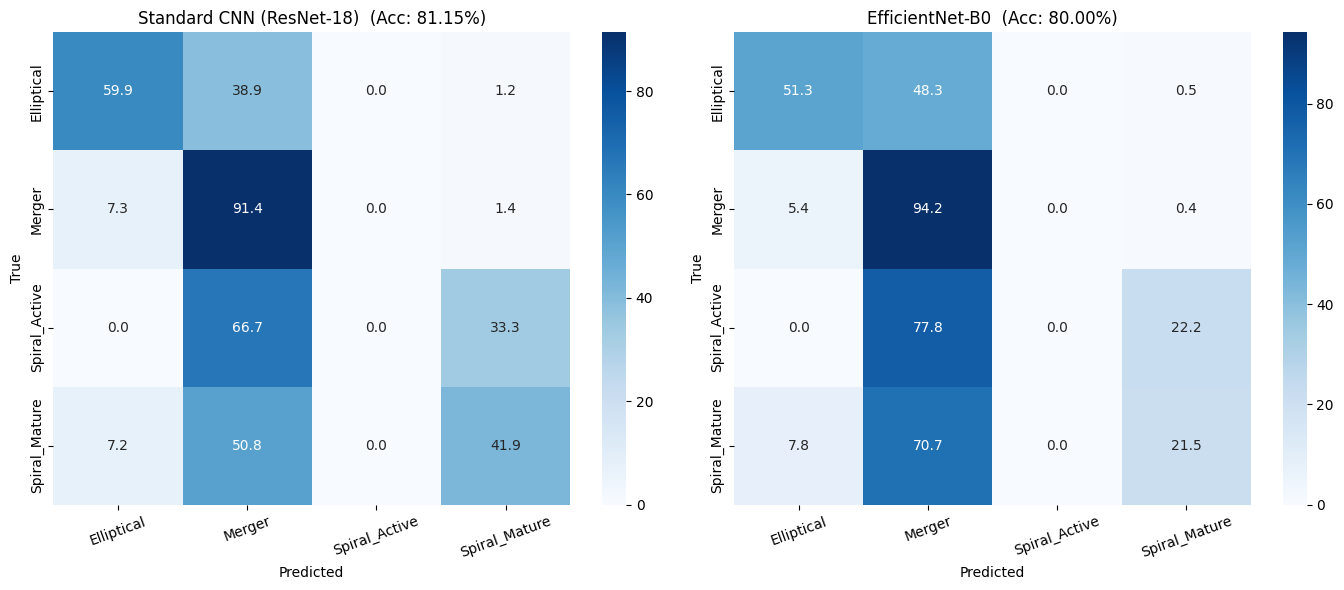

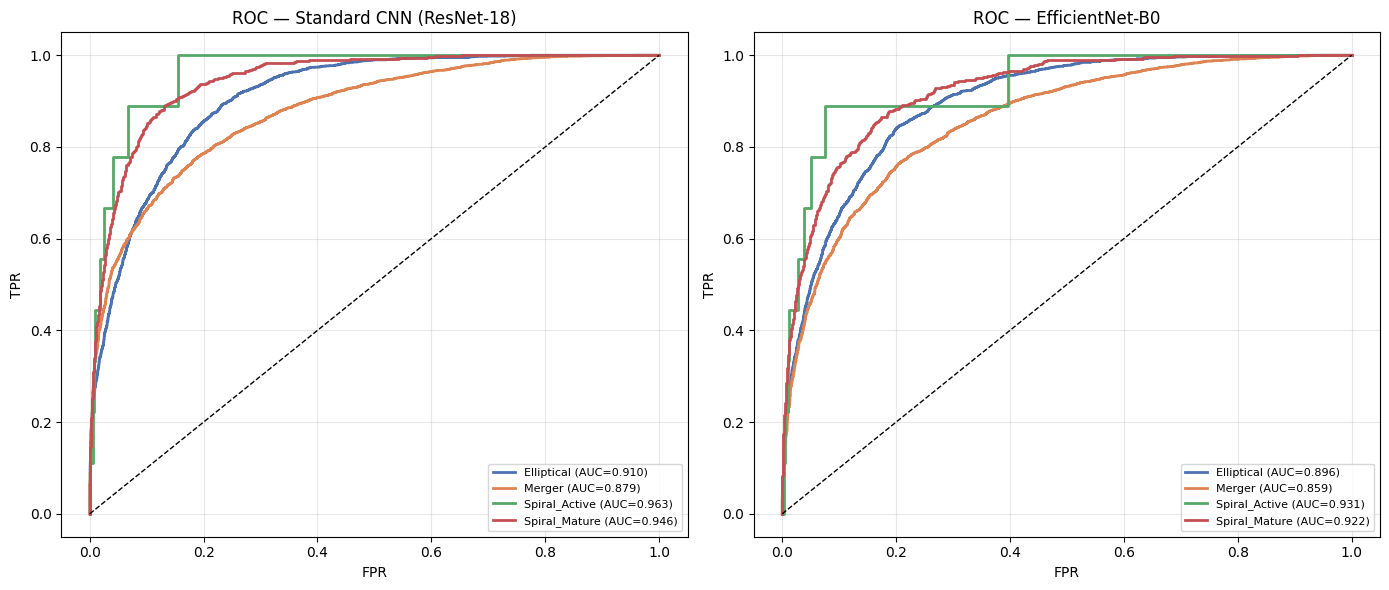


✅ STEP 8 — Evaluation done


In [18]:
# ================================================================
# STEP 8: MODEL EVALUATION
# ================================================================
def evaluate_model(model, loader, model_name):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for imgs, labels in loader:
            out   = model(imgs.to(DEVICE))
            probs = torch.softmax(out, dim=1).cpu().numpy()
            all_probs.extend(probs)
            all_preds.extend(out.argmax(1).cpu().numpy())
            all_labels.extend(labels.numpy())

    all_probs  = np.array(all_probs)
    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)

    acc       = np.mean(all_preds == all_labels)
    precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    recall    = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    f1        = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    labs_bin  = label_binarize(all_labels, classes=list(range(NUM_CLASSES)))
    roc_auc   = roc_auc_score(labs_bin, all_probs, multi_class='ovr', average='weighted')

    print(f"\n{'─'*50}")
    print(f"  {model_name}  |  Test Acc: {acc*100:.2f}%")
    print(f"{'─'*50}")
    print(f"  Precision : {precision:.4f}")
    print(f"  Recall    : {recall:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    print(f"  ROC-AUC   : {roc_auc:.4f}")
    print(f"\n{classification_report(all_labels, all_preds, target_names=CLASS_NAMES)}")
    return {'name':model_name,'acc':acc,'precision':precision,'recall':recall,
            'f1':f1,'roc_auc':roc_auc,'preds':all_preds,'labels':all_labels,'probs':all_probs}

results_cnn = evaluate_model(model_cnn, test_loader, 'Standard CNN (ResNet-18)')
results_eff = evaluate_model(model_eff, test_loader, 'EfficientNet-B0')

# ---- Confusion Matrices ----
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, res in [(axes[0], results_cnn), (axes[1], results_eff)]:
    cm = confusion_matrix(res['labels'], res['preds'])
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues', ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    ax.set_title(f"{res['name']}  (Acc: {res['acc']*100:.2f}%)")
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig(f'{DRIVE_SAVE}/confusion_matrices.png', dpi=150)
plt.show()

# ---- ROC Curves ----
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = ['#4C72B0','#DD8452','#55A868','#C44E52']
for ax, res in [(axes[0], results_cnn), (axes[1], results_eff)]:
    labs_bin = label_binarize(res['labels'], classes=list(range(NUM_CLASSES)))
    for i, (cls, col) in enumerate(zip(CLASS_NAMES, colors)):
        fpr, tpr, _ = roc_curve(labs_bin[:, i], res['probs'][:, i])
        ax.plot(fpr, tpr, color=col, lw=2, label=f'{cls} (AUC={auc(fpr,tpr):.3f})')
    ax.plot([0,1],[0,1],'k--', lw=1)
    ax.set_title(f"ROC — {res['name']}")
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.legend(loc='lower right', fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{DRIVE_SAVE}/roc_curves.png', dpi=150)
plt.show()

print("\n✅ STEP 8 — Evaluation done")

Grid: 6 configs × 2 epochs on 20% subset (~5 min total)

  LR=0.0001, Dropout=0.3 ... Val: 71.12%
  LR=0.0001, Dropout=0.5 ... Val: 71.42%
  LR=0.0005, Dropout=0.3 ... Val: 74.13%
  LR=0.0005, Dropout=0.5 ... Val: 74.70%
  LR=0.001, Dropout=0.3 ... Val: 72.21%
  LR=0.001, Dropout=0.5 ... Val: 75.51%

Tuning Results:
    lr  dropout  val_acc
0.0010      0.5   0.7551
0.0005      0.5   0.7470
0.0005      0.3   0.7413
0.0010      0.3   0.7221
0.0001      0.5   0.7142
0.0001      0.3   0.7112

✅ Best → LR: 0.001 | Dropout: 0.5


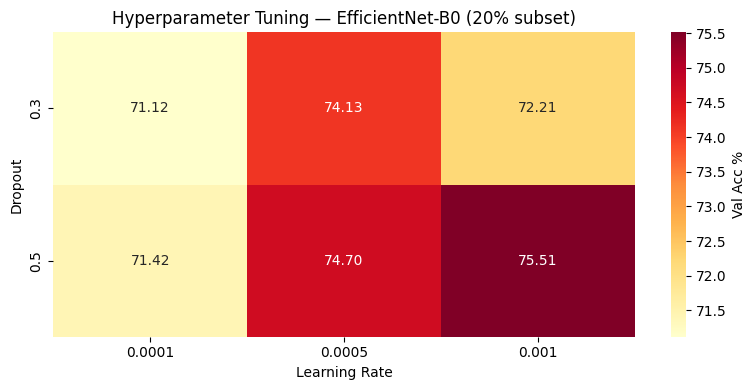


✅ STEP 9 — Hyperparameter Tuning done


In [20]:
# ================================================================
# STEP 9: HYPERPARAMETER TUNING (Fast - Subset based)
# ================================================================
import random

# Use only 20% of training data for tuning speed
def get_subset_loader(loader, fraction=0.2):
    dataset = loader.dataset
    n = int(len(dataset) * fraction)
    indices = random.sample(range(len(dataset)), n)
    subset = torch.utils.data.Subset(dataset, indices)
    return torch.utils.data.DataLoader(subset, batch_size=64,
                                       shuffle=True, num_workers=2)

subset_loader = get_subset_loader(train_loader_cnn, fraction=0.2)

def quick_eval(model, loader):
    model.eval(); correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            out = model(imgs.to(DEVICE))
            correct += (out.argmax(1) == labels.to(DEVICE)).sum().item()
            total   += labels.size(0)
    return correct / total

def quick_train(model, t_loader, lr, epochs=2):
    model = model.to(DEVICE)
    opt  = optim.Adam(model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()
    best = 0.0
    for _ in range(epochs):
        model.train()
        for imgs, labels in t_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            opt.zero_grad()
            loss = crit(model(imgs), labels)
            loss.backward(); opt.step()
        va = quick_eval(model, val_loader)
        if va > best: best = va
    return best

param_grid = {'lr': [1e-4, 5e-4, 1e-3], 'dropout': [0.3, 0.5]}
tuning_results = []

print(f"Grid: 6 configs × 2 epochs on 20% subset (~5 min total)\n")
for lr_val in param_grid['lr']:
    for drop_val in param_grid['dropout']:
        print(f"  LR={lr_val}, Dropout={drop_val} ...", end=' ', flush=True)
        m = build_efficientnet(dropout=drop_val)
        va = quick_train(m, subset_loader, lr=lr_val, epochs=2)
        tuning_results.append({'lr': lr_val, 'dropout': drop_val, 'val_acc': round(va, 4)})
        print(f"Val: {va*100:.2f}%")
        del m; torch.cuda.empty_cache()

tuning_df = pd.DataFrame(tuning_results).sort_values('val_acc', ascending=False)
print(f"\nTuning Results:\n{tuning_df.to_string(index=False)}")
best_lr      = tuning_df.iloc[0]['lr']
best_dropout = tuning_df.iloc[0]['dropout']
print(f"\n✅ Best → LR: {best_lr} | Dropout: {best_dropout}")

pivot = tuning_df.pivot(index='dropout', columns='lr', values='val_acc')
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(pivot*100, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax,
            cbar_kws={'label': 'Val Acc %'})
ax.set_title('Hyperparameter Tuning — EfficientNet-B0 (20% subset)')
ax.set_xlabel('Learning Rate'); ax.set_ylabel('Dropout')
plt.tight_layout()
plt.savefig(f'{DRIVE_SAVE}/hyperparameter_heatmap.png', dpi=150)
plt.show()
print("\n✅ STEP 9 — Hyperparameter Tuning done")

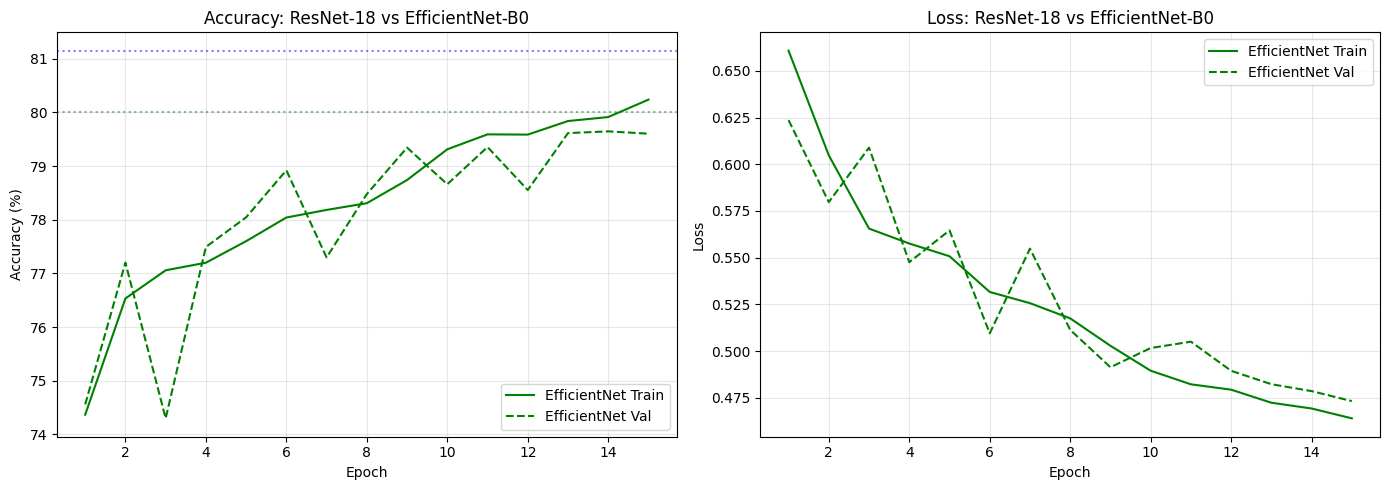

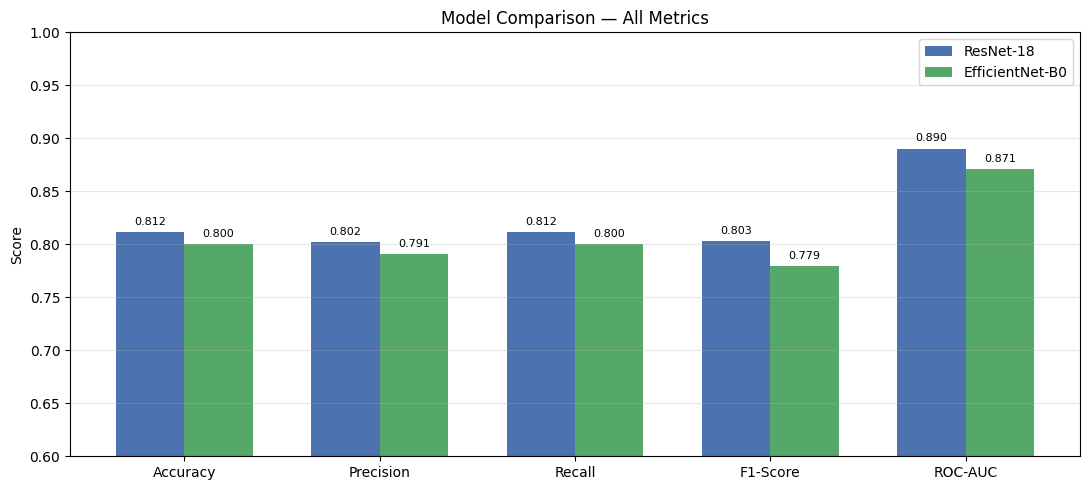


  FINAL PROJECT SUMMARY
  Dataset        : Galaxy Zoo (61,578 images, 4 classes)
  Best Model     : ResNet-18 (Standard CNN)
  Test Accuracy  : 81.15%
  F1-Score       : 0.8031
  ROC-AUC        : 0.8903
  Best HP        : LR=0.001, Dropout=0.5

🎉 PROJECT COMPLETE — All plots saved to Drive!


In [21]:
# ================================================================
# STEP 10: FINAL COMPARISON PLOTS
# ================================================================

ep_cnn = range(1, len(hist_cnn['train_acc'])+1) if hist_cnn['train_acc'] else range(1,2)
ep_eff = range(1, len(hist_eff['train_acc'])+1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---- Accuracy Curves ----
ax = axes[0]
if hist_cnn['train_acc']:
    ax.plot(ep_cnn, [a*100 for a in hist_cnn['train_acc']], 'b-',  label='ResNet-18 Train')
    ax.plot(ep_cnn, [a*100 for a in hist_cnn['val_acc']],   'b--', label='ResNet-18 Val')
ax.plot(ep_eff, [a*100 for a in hist_eff['train_acc']], 'g-',  label='EfficientNet Train')
ax.plot(ep_eff, [a*100 for a in hist_eff['val_acc']],   'g--', label='EfficientNet Val')
ax.set_title('Accuracy: ResNet-18 vs EfficientNet-B0')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)')
ax.legend(); ax.grid(True, alpha=0.3)
ax.axhline(y=81.15, color='blue', linestyle=':', alpha=0.5, label='CNN Best')
ax.axhline(y=80.00, color='green', linestyle=':', alpha=0.5, label='Eff Best')

# ---- Loss Curves ----
ax = axes[1]
if hist_cnn['train_loss']:
    ax.plot(ep_cnn, hist_cnn['train_loss'], 'b-',  label='ResNet-18 Train')
    ax.plot(ep_cnn, hist_cnn['val_loss'],   'b--', label='ResNet-18 Val')
ax.plot(ep_eff, hist_eff['train_loss'], 'g-',  label='EfficientNet Train')
ax.plot(ep_eff, hist_eff['val_loss'],   'g--', label='EfficientNet Val')
ax.set_title('Loss: ResNet-18 vs EfficientNet-B0')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{DRIVE_SAVE}/training_curves.png', dpi=150)
plt.show()

# ---- Final Bar Chart ----
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
cnn_vals = [results_cnn['acc'],       results_cnn['precision'],
            results_cnn['recall'],     results_cnn['f1'],
            results_cnn['roc_auc']]
eff_vals = [results_eff['acc'],       results_eff['precision'],
            results_eff['recall'],     results_eff['f1'],
            results_eff['roc_auc']]

x = np.arange(len(metrics)); width = 0.35
fig, ax = plt.subplots(figsize=(11, 5))
bars1 = ax.bar(x - width/2, cnn_vals, width, label='ResNet-18',     color='#4C72B0')
bars2 = ax.bar(x + width/2, eff_vals, width, label='EfficientNet-B0', color='#55A868')
ax.set_title('Model Comparison — All Metrics')
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylim(0.6, 1.0); ax.set_ylabel('Score')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
for bar in bars1: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                           f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars2: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                           f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig(f'{DRIVE_SAVE}/model_comparison.png', dpi=150)
plt.show()

# ---- Final Summary ----
print("\n" + "="*55)
print("  FINAL PROJECT SUMMARY")
print("="*55)
print(f"  Dataset        : Galaxy Zoo (61,578 images, 4 classes)")
print(f"  Best Model     : ResNet-18 (Standard CNN)")
print(f"  Test Accuracy  : {results_cnn['acc']*100:.2f}%")
print(f"  F1-Score       : {results_cnn['f1']:.4f}")
print(f"  ROC-AUC        : {results_cnn['roc_auc']:.4f}")
print(f"  Best HP        : LR=0.001, Dropout=0.5")
print("="*55)
print("\n🎉 PROJECT COMPLETE — All plots saved to Drive!")

DEMO

In [24]:
# Check all variables
print("test_loader:", 'test_loader' in dir())
print("model_cnn:  ", 'model_cnn' in dir())
print("DEVICE:     ", 'DEVICE' in dir())
print("DRIVE_SAVE: ", 'DRIVE_SAVE' in dir())

test_loader: True
model_cnn:   True
DEVICE:      True
DRIVE_SAVE:  True


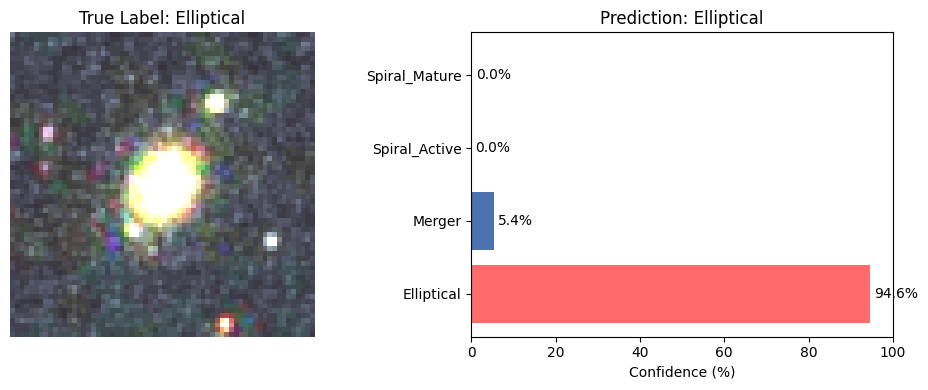


True Label  : Elliptical
Predicted   : Elliptical
Confidence  : 94.6%
Correct?    : ✅ YES


In [25]:
import matplotlib.pyplot as plt
import random

test_dataset = test_loader.dataset
idx = random.randint(0, len(test_dataset)-1)
img_tensor, true_label = test_dataset[idx]

CLASS_NAMES = ['Elliptical', 'Merger', 'Spiral_Active', 'Spiral_Mature']

model_cnn.eval()
with torch.no_grad():
    output = model_cnn(img_tensor.unsqueeze(0).to(DEVICE))
    probs  = torch.softmax(output, dim=1)[0].cpu()  # .cpu() added

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# .cpu() added here ↓
img_show = img_tensor.cpu().permute(1,2,0).numpy()
img_show = (img_show * 0.5) + 0.5
axes[0].imshow(img_show.clip(0,1))
axes[0].set_title(f'True Label: {CLASS_NAMES[true_label]}')
axes[0].axis('off')

colors = ['#ff6b6b' if i == probs.argmax() else '#4C72B0' for i in range(4)]
axes[1].barh(CLASS_NAMES, probs.numpy()*100, color=colors)
axes[1].set_xlabel('Confidence (%)')
axes[1].set_title(f'Prediction: {CLASS_NAMES[probs.argmax()]}')
axes[1].set_xlim(0, 100)
for i, prob in enumerate(probs):
    axes[1].text(prob*100 + 1, i, f'{prob*100:.1f}%', va='center')

plt.tight_layout()
plt.savefig(f'{DRIVE_SAVE}/sample_prediction.png', dpi=150)
plt.show()

print(f"\nTrue Label  : {CLASS_NAMES[true_label]}")
print(f"Predicted   : {CLASS_NAMES[probs.argmax()]}")
print(f"Confidence  : {probs.max()*100:.1f}%")
print(f"Correct?    : {'✅ YES' if probs.argmax() == true_label else '❌ NO'}")